# Notebook 3 — Does the synth help a detector?

**Workshop path:** depends on [Notebook 2](02_batch_dataset_generation.ipynb) export under `outputs/<dataset>/nb2/`.

Business question: fine-tune a small detector on **real-only** vs **real + synthetic**, evaluate both on the **same held-out real test**.

Pretty edits that fail this A/B are demos, not data products.


---
## Why this protocol?

| Choice | Why |
|--------|-----|
| **Same real test** | Isolates train-set composition; no synth in eval |
| **COCO-pretrained YOLOv8n** | Starts without our rare classes — room to show lift |
| **Fractions of NB2 accepts** | `50%` / `100%` of *usable* synth (not hardcoded 50/100 images) |
| **Rare-class AP@0.5** | Operational metric; mAP can hide a weak rare class |

### How to generalize beyond this bootcamp

1. Freeze a real holdout **before** synthesizing.
2. Define “usable synth” (here: has a target box + passed judge).
3. Sweep synth dose; plot rare-class AP (figure F3).
4. Inspect failure modes (label noise, domain gap, too-easy / near-dupe synth).
5. **Do not assume more synth ⇒ better** — a class can peak then drop.


---
## 0. Setup


In [1]:
from pathlib import Path

from aieng.syn_data.image.bootstrap import bootstrap_project_root
from aieng.syn_data.image.config import load_env


PROJECT_ROOT = bootstrap_project_root()
load_env(PROJECT_ROOT)
print("PROJECT_ROOT =", PROJECT_ROOT)

/home/coder/synthetic-data-bootcamp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT = /home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation


---
## 1. Knobs + load NB2 manifests


In [2]:
import os


os.environ.setdefault("HF_HUB_DISABLE_XET", "1")


from aieng.syn_data.image.config import load_config
from aieng.syn_data.image.detection_train import load_manifest


DATASET = "mapillary_vistas"
HARDWARE = "gpu_l4"
CLASS_NAMES = ["traffic_cone", "trash_bin"]
LABEL_ALIASES = {
    "traffic_cone": ["traffic cone", "orange cone", "cone"],
    "trash_bin": ["trash can", "garbage bin", "waste bin", "dumpster"],
}
MODEL = "yolov8n.pt"
EPOCHS = 40
IMGSZ = 640
BATCH = 16
PATIENCE = 15
SEED = 42
MAX_SCENE_TRAIN = 150
NB2_DIR_NAME = "nb2"

cfg = load_config(
    start=PROJECT_ROOT,
    overrides=[f"dataset_name={DATASET}", f"hardware={HARDWARE}"],
)
nb2_dir = Path(cfg.paths.outputs_dir) / NB2_DIR_NAME
out_dir = Path(cfg.paths.outputs_dir) / "nb3"
out_dir.mkdir(parents=True, exist_ok=True)
train_manifest_path = nb2_dir / "train_manifest.json"
test_manifest_path = nb2_dir / "test_manifest.json"
if not train_manifest_path.exists() or not test_manifest_path.exists():
    raise FileNotFoundError(f"Missing NB2 export under {nb2_dir}")

train_manifest = load_manifest(train_manifest_path)
test_manifest = load_manifest(test_manifest_path)
device = str(cfg.hardware.get("device", "cpu"))
print(f"Train rows={len(train_manifest)}  Test rows={len(test_manifest)}")
print(f"Classes={CLASS_NAMES}  device={device}")

Train rows=418  Test rows=150
Classes=['traffic_cone', 'trash_bin']  device=cuda


---
## 2. Build three YOLO datasets

- `real_only`
- `real_synth_50` — 50% of usable NB2 accepts per class
- `real_synth_100` — all usable accepts

Cap empty `scene` backgrounds (`MAX_SCENE_TRAIN`) so rare boxes are not drowned.


In [3]:
from aieng.syn_data.image.detection_train import (
    build_yolo_dataset,
    count_usable_synthetic,
    synth_caps_for_fraction,
)


ds_root = out_dir / "datasets"
available_synth = count_usable_synthetic(train_manifest, class_names=CLASS_NAMES, aliases=LABEL_ALIASES)
caps_half = synth_caps_for_fraction(train_manifest, fraction=0.5, class_names=CLASS_NAMES, aliases=LABEL_ALIASES)
caps_full = synth_caps_for_fraction(train_manifest, fraction=1.0, class_names=CLASS_NAMES, aliases=LABEL_ALIASES)
print("usable NB2 synth:", available_synth)
print("caps 50% / 100%:", caps_half, caps_full)

yaml_real, tr_real, va_real = build_yolo_dataset(
    train_manifest=train_manifest,
    test_manifest=test_manifest,
    out_dir=ds_root / "real_only",
    class_names=CLASS_NAMES,
    aliases=LABEL_ALIASES,
    include_synthetic=False,
    max_scene_images=MAX_SCENE_TRAIN,
    scene_sample_seed=SEED,
    dataset_name="real_only",
)
yaml_s50, tr_s50, va_s50 = build_yolo_dataset(
    train_manifest=train_manifest,
    test_manifest=test_manifest,
    out_dir=ds_root / "real_synth_50",
    class_names=CLASS_NAMES,
    aliases=LABEL_ALIASES,
    include_synthetic=True,
    synthetic_fraction=0.5,
    max_scene_images=MAX_SCENE_TRAIN,
    scene_sample_seed=SEED,
    dataset_name="real_synth_50",
)
yaml_s100, tr_s100, va_s100 = build_yolo_dataset(
    train_manifest=train_manifest,
    test_manifest=test_manifest,
    out_dir=ds_root / "real_synth_100",
    class_names=CLASS_NAMES,
    aliases=LABEL_ALIASES,
    include_synthetic=True,
    synthetic_fraction=1.0,
    max_scene_images=MAX_SCENE_TRAIN,
    scene_sample_seed=SEED,
    dataset_name="real_synth_100",
)


def _print_stats(title, train_s, val_s):
    print(title)
    print(
        f"  train: images={train_s.n_images} real={train_s.n_real} "
        f"synth={train_s.n_synthetic} boxes={train_s.n_boxes} per_class={train_s.boxes_per_class}",
    )
    print(f"  val:   images={val_s.n_images} boxes={val_s.n_boxes} per_class={val_s.boxes_per_class}")


_print_stats("real_only", tr_real, va_real)
_print_stats("real_synth_50", tr_s50, va_s50)
_print_stats("real_synth_100", tr_s100, va_s100)

usable NB2 synth: {'traffic_cone': 49, 'trash_bin': 89}
caps 50% / 100%: {'traffic_cone': 24, 'trash_bin': 44} {'traffic_cone': 49, 'trash_bin': 89}
real_only
  train: images=200 real=200 synth=0 boxes=108 per_class={'traffic_cone': 45, 'trash_bin': 63}
  val:   images=150 boxes=179 per_class={'trash_bin': 79, 'traffic_cone': 100}
real_synth_50
  train: images=268 real=200 synth=68 boxes=217 per_class={'traffic_cone': 75, 'trash_bin': 142}
  val:   images=150 boxes=179 per_class={'trash_bin': 79, 'traffic_cone': 100}
real_synth_100
  train: images=338 real=200 synth=138 boxes=326 per_class={'traffic_cone': 104, 'trash_bin': 222}
  val:   images=150 boxes=179 per_class={'trash_bin': 79, 'traffic_cone': 100}


---
## 3. Train three short fine-tunes
> Runtime on `HARDWARE="gpu_l4"` with ~140 synthetic images: ~5mins

Same hyperparameters; only the train mix changes.


In [4]:
from aieng.syn_data.image.detection_train import train_detector


runs_dir = out_dir / "runs"
run_real = train_detector(
    yaml_real,
    name="real_only",
    project_dir=runs_dir,
    model_name=MODEL,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=device,
    seed=SEED,
    patience=PATIENCE,
)
print("real_only", run_real.metrics)

run_synth_50 = train_detector(
    yaml_s50,
    name="real_synth_50",
    project_dir=runs_dir,
    model_name=MODEL,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=device,
    seed=SEED,
    patience=PATIENCE,
)
print("real_synth_50", run_synth_50.metrics)

run_synth_100 = train_detector(
    yaml_s100,
    name="real_synth_100",
    project_dir=runs_dir,
    model_name=MODEL,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=device,
    seed=SEED,
    patience=PATIENCE,
)
print("real_synth_100", run_synth_100.metrics)

New https://pypi.org/project/ultralytics/8.4.155 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.148 🚀 Python-3.12.14 torch-2.14.0+cu130 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation/outputs/mapillary_vistas/nb3/datasets/real_only/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, ko

---
## 4. F3 — dose–response on held-out real test

Compare mAP and **per-class AP@0.5**. A class that rises then falls (or never rises) is a teaching moment: synth quality, label noise, or imbalance — not a notebook bug.


run                 mAP50  mAP50-95   AP50 traffic_cone      AP50 trash_bin
real_only           0.068     0.031               0.106               0.029
real_synth_50       0.081     0.042               0.103               0.058
real_synth_100      0.079     0.047               0.094               0.065


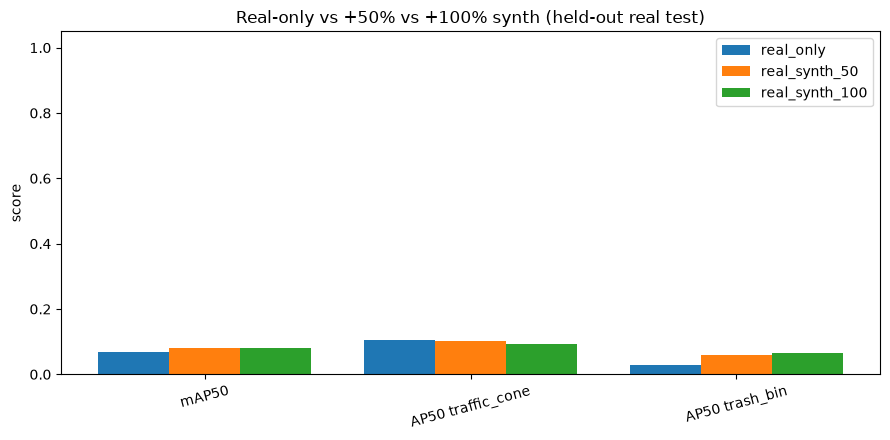

In [5]:
import matplotlib.pyplot as plt
from aieng.syn_data.image.detection_train import metrics_table, plot_map_comparison
from aieng.syn_data.image.eda import write_json


runs = [run_real, run_synth_50, run_synth_100]
table = metrics_table(runs)
print(f"{'run':16s}  {'mAP50':>7s}  {'mAP50-95':>8s}", end="")
for cls in CLASS_NAMES:
    print(f"  {('AP50 ' + cls):>18s}", end="")
print()
for row in table:
    print(
        f"{row['run']:16s}  {float(row['map50'] or 0):7.3f}  {float(row['map50_95'] or 0):8.3f}",
        end="",
    )
    for cls in CLASS_NAMES:
        print(f"  {float(row.get(f'ap50_{cls}') or 0):18.3f}", end="")
    print()

write_json(out_dir / "comparison.json", table)
fig, _ = plot_map_comparison(runs, title="Real-only vs +50% vs +100% synth (held-out real test)")
fig.savefig(out_dir / "comparison.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 5. Qualitative gallery

Same test images under each checkpoint — look for true positives that appear only after synth, and for new false positives.


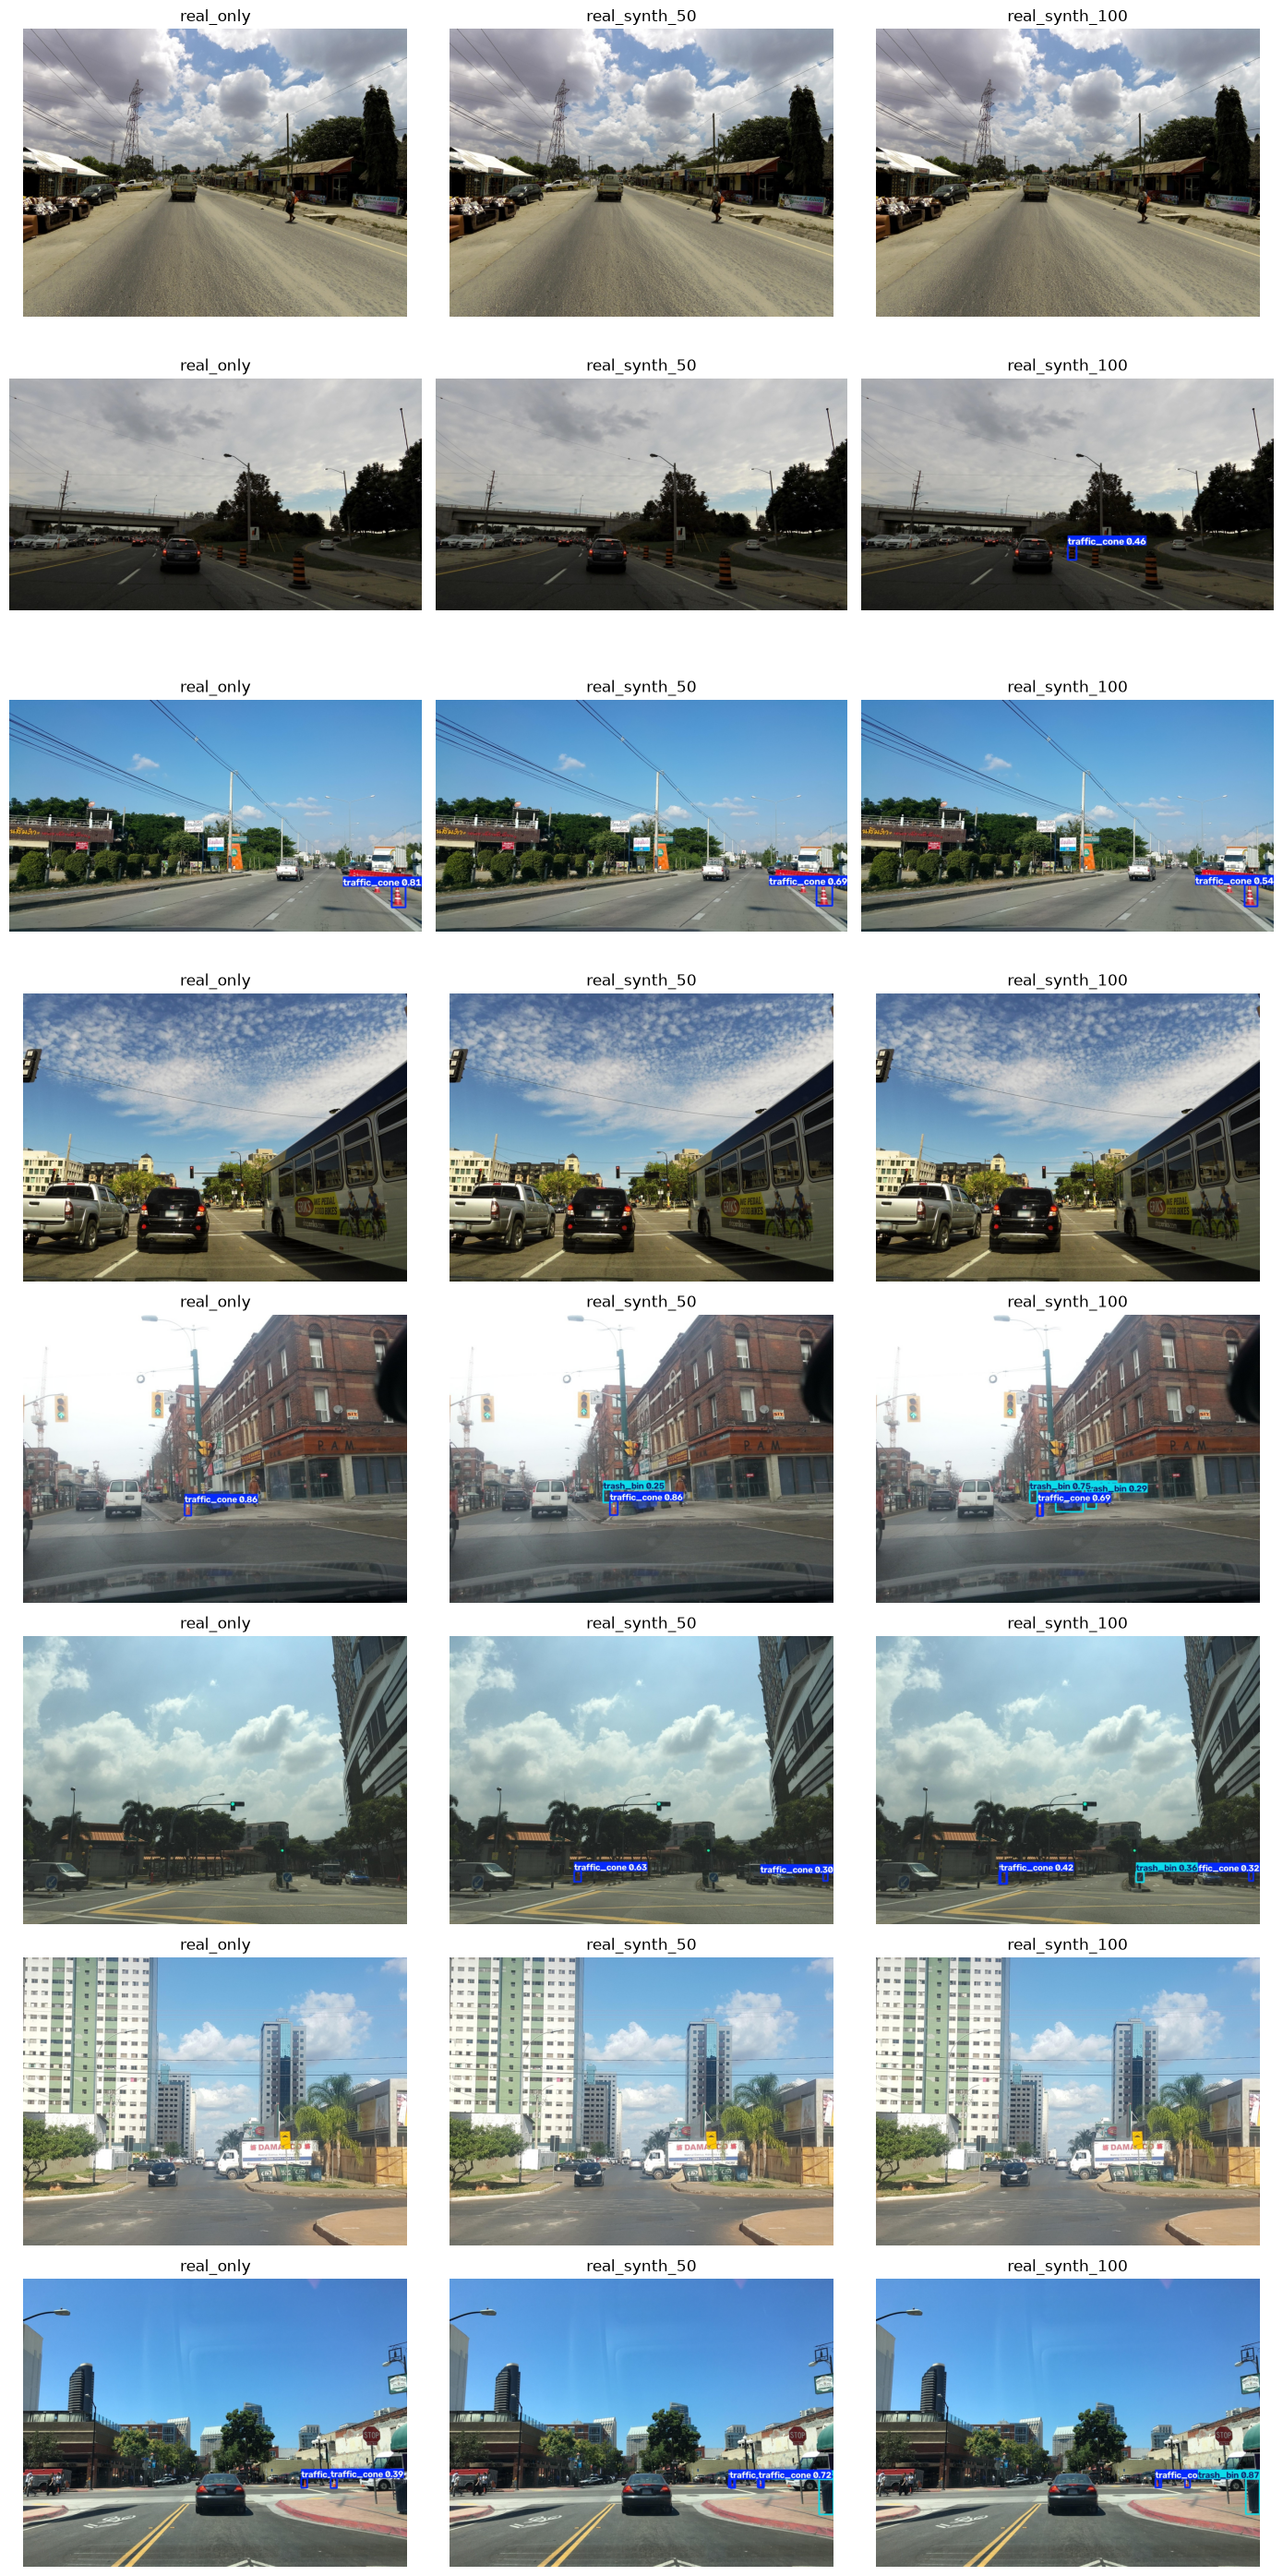

In [6]:
import matplotlib.pyplot as plt
from aieng.syn_data.image.detection_train import predict_gallery
from PIL import Image


rare_test = [Path(r["path"]) for r in test_manifest if str(r.get("tag", "")) in CLASS_NAMES]
scene_test = [Path(r["path"]) for r in test_manifest if str(r.get("tag", "")) == "scene"]
gallery_paths = (rare_test + scene_test)[:8]

gal_real = predict_gallery(run_real.weights, gallery_paths, out_dir=out_dir / "gallery_real_only", device=device)
gal_s50 = predict_gallery(run_synth_50.weights, gallery_paths, out_dir=out_dir / "gallery_real_synth_50", device=device)
gal_s100 = predict_gallery(
    run_synth_100.weights,
    gallery_paths,
    out_dir=out_dir / "gallery_real_synth_100",
    device=device,
)

n = min(len(gallery_paths), len(gal_real), len(gal_s50), len(gal_s100))
if n:
    fig, axes = plt.subplots(n, 3, figsize=(14, 3.5 * n))
    if n == 1:
        axes = axes.reshape(1, -1)
    for i in range(n):
        for j, (path, title) in enumerate(
            ((gal_real[i], "real_only"), (gal_s50[i], "real_synth_50"), (gal_s100[i], "real_synth_100")),
        ):
            axes[i, j].imshow(Image.open(path))
            axes[i, j].set_title(title)
            axes[i, j].axis("off")
    plt.tight_layout()
    fig.savefig(out_dir / "gallery_compare.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("No gallery images produced.")

---
## Wrap-up

- You measured whether **accepted** synth moves rare-class detection on real photos.
- If one class regresses at 100% synth, tighten NB1/NB2 gates or variations — or use the mid dose.
- Protocol to reuse on your data: freeze real test → define usable synth → dose sweep → inspect errors.

Figures: [figures.md](../docs/figures.md) · Citations: [citations.md](../docs/citations.md).
